In [33]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import  pandas as pd
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary
import torch.optim as optim

In [42]:
df = pd.read_csv('fmnist_small.csv')

In [43]:
df.head(10)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
5,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,...,130,0,0,0,0,0,0,0,0,0
9,0,0,0,0,1,1,3,0,0,0,...,80,77,83,45,0,0,0,1,0,0


In [44]:
torch.manual_seed(42)

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

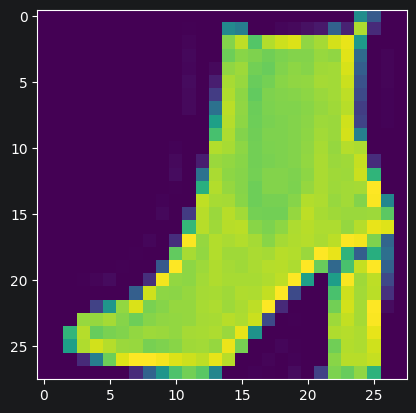

In [46]:
plt.imshow(df.iloc[0, 1:].values.reshape(28, 28))

In [47]:
X = df.iloc[:,1:].values
y= df.iloc[:,0].values

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [50]:
X_train= X_train/255.0
X_test= X_test/255.0

In [51]:
class CustomLoader(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index) :
        return self.X[index], self.y[index]

In [52]:
train_dataset = CustomLoader(X_train, y_train)
test_dataset = CustomLoader(X_test, y_test)

In [53]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True, pin_memory=True)

In [54]:
class SimpleNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, 10)
        )

    def forward(self,X):
        return self.model(X)

In [55]:
model= SimpleNN(train_dataset.X.shape[1])
learning_rate=0.01
optimizer = optim.Adam(model.parameters(),lr=learning_rate, weight_decay=1e-4)
model.to(device)
epochs =100

In [56]:
criterion = nn.CrossEntropyLoss()

In [57]:
for epoch in range(epochs):
    total_epoch_loss = 0

    for batch_features , batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()

    avg_epoch_loss = total_epoch_loss/len(train_loader)

    print("Epoch : ",epoch+1)
    print("Average Loss : ",avg_epoch_loss)

Epoch :  1
Average Loss :  0.9335866864522299
Epoch :  2
Average Loss :  0.7048183739185333
Epoch :  3
Average Loss :  0.6441594195365906
Epoch :  4
Average Loss :  0.6027184744675954
Epoch :  5
Average Loss :  0.5751308903098107
Epoch :  6
Average Loss :  0.5792960588137309
Epoch :  7
Average Loss :  0.5644905914862951
Epoch :  8
Average Loss :  0.540735331773758
Epoch :  9
Average Loss :  0.5299989223480225
Epoch :  10
Average Loss :  0.5259378392497699
Epoch :  11
Average Loss :  0.5098941696683565
Epoch :  12
Average Loss :  0.5097228354215622
Epoch :  13
Average Loss :  0.5118449840943019
Epoch :  14
Average Loss :  0.5243831753730774
Epoch :  15
Average Loss :  0.5084797524412473
Epoch :  16
Average Loss :  0.49563939511775973
Epoch :  17
Average Loss :  0.49495356758435566
Epoch :  18
Average Loss :  0.5143580039342245
Epoch :  19
Average Loss :  0.4963484099507332
Epoch :  20
Average Loss :  0.48689572791258495
Epoch :  21
Average Loss :  0.5025587300459544
Epoch :  22
Average 

In [58]:
model.eval()

SimpleNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [59]:
total =0
correct=0
with torch.no_grad():
    for batch_features , batch_labels in test_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total += batch_labels.shape[0]
        correct += (predicted == batch_labels).sum().item()

    print(correct/total)

0.8208333333333333


In [60]:
total =0
correct=0
with torch.no_grad():
    for batch_features , batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total += batch_labels.shape[0]
        correct += (predicted == batch_labels).sum().item()

    print(correct/total)

0.8983333333333333
